### EDA

In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [202]:
# Load the dataset
df = pd.read_csv('../data/raw_data.csv')
df.head()

,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,date_of_birth,entry_service_date,city,...,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity
0,physiotherapy,13:20,M,09/09/2021,yes,surto,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
1,psychotherapy,13:20,M,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
2,speech therapy,13:20,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
3,physiotherapy,13:20,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
4,physiotherapy,14:00,M,09/09/2021,no,NaN,motor,10/10/1954,5/2/2020,B. CAMBORIU,...,1,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild


In [203]:
df.tail()

,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,date_of_birth,entry_service_date,city,...,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity
49588,NaN,10:20,M,01/02/2022,yes,pai tem médico,intellectual,9/3/2009,5/11/2019,ITAJAÍ,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49589,NaN,10:20,M,01/02/2022,yes,NaN,NaN,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49590,NaN,11:00,M,01/02/2022,no,NaN,intellectual,7/3/2016,11/2/2020,BOMBINHAS,...,0,1,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49591,psychotherapy,11:00,M,01/02/2022,yes,NaN,NaN,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49592,NaN,11:00,M,01/02/2022,no,NaN,intellectual,25/4/2016,2/9/2020,ITAJAÍ,...,0,1,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49593 entries, 0 to 49592
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   specialty                42139 non-null  object 
 1   appointment_time         49593 non-null  object 
 2   gender                   49593 non-null  object 
 3   appointment_date         49593 non-null  object 
 4   no_show                  49593 non-null  object 
 5   no_show_reason           1737 non-null   object 
 6   disability               44456 non-null  object 
 7   date_of_birth            39272 non-null  object 
 8   entry_service_date       44438 non-null  object 
 9   city                     44412 non-null  object 
 10  icd                      10717 non-null  object 
 11  appointment_month        49593 non-null  object 
 12  appointment_year         49593 non-null  int64  
 13  appointment_shift        49593 non-null  object 
 14  age                   

In [205]:
# Check for the numbers of unique values in each column
df.nunique()

specialty                     8
appointment_time             74
gender                        3
appointment_date           1001
no_show                       2
no_show_reason              341
disability                    3
date_of_birth               954
entry_service_date          333
city                         13
icd                          63
appointment_month            12
appointment_year              7
appointment_shift             2
age                          87
under_12_years_old            2
over_60_years_old             2
patient_needs_companion       2
average_temp_day            677
average_rain_day            130
max_temp_day                185
max_rain_day                 84
rainy_day_before              2
storm_day_before              2
rain_intensity                4
heat_intensity                5
dtype: int64

<Axes: >

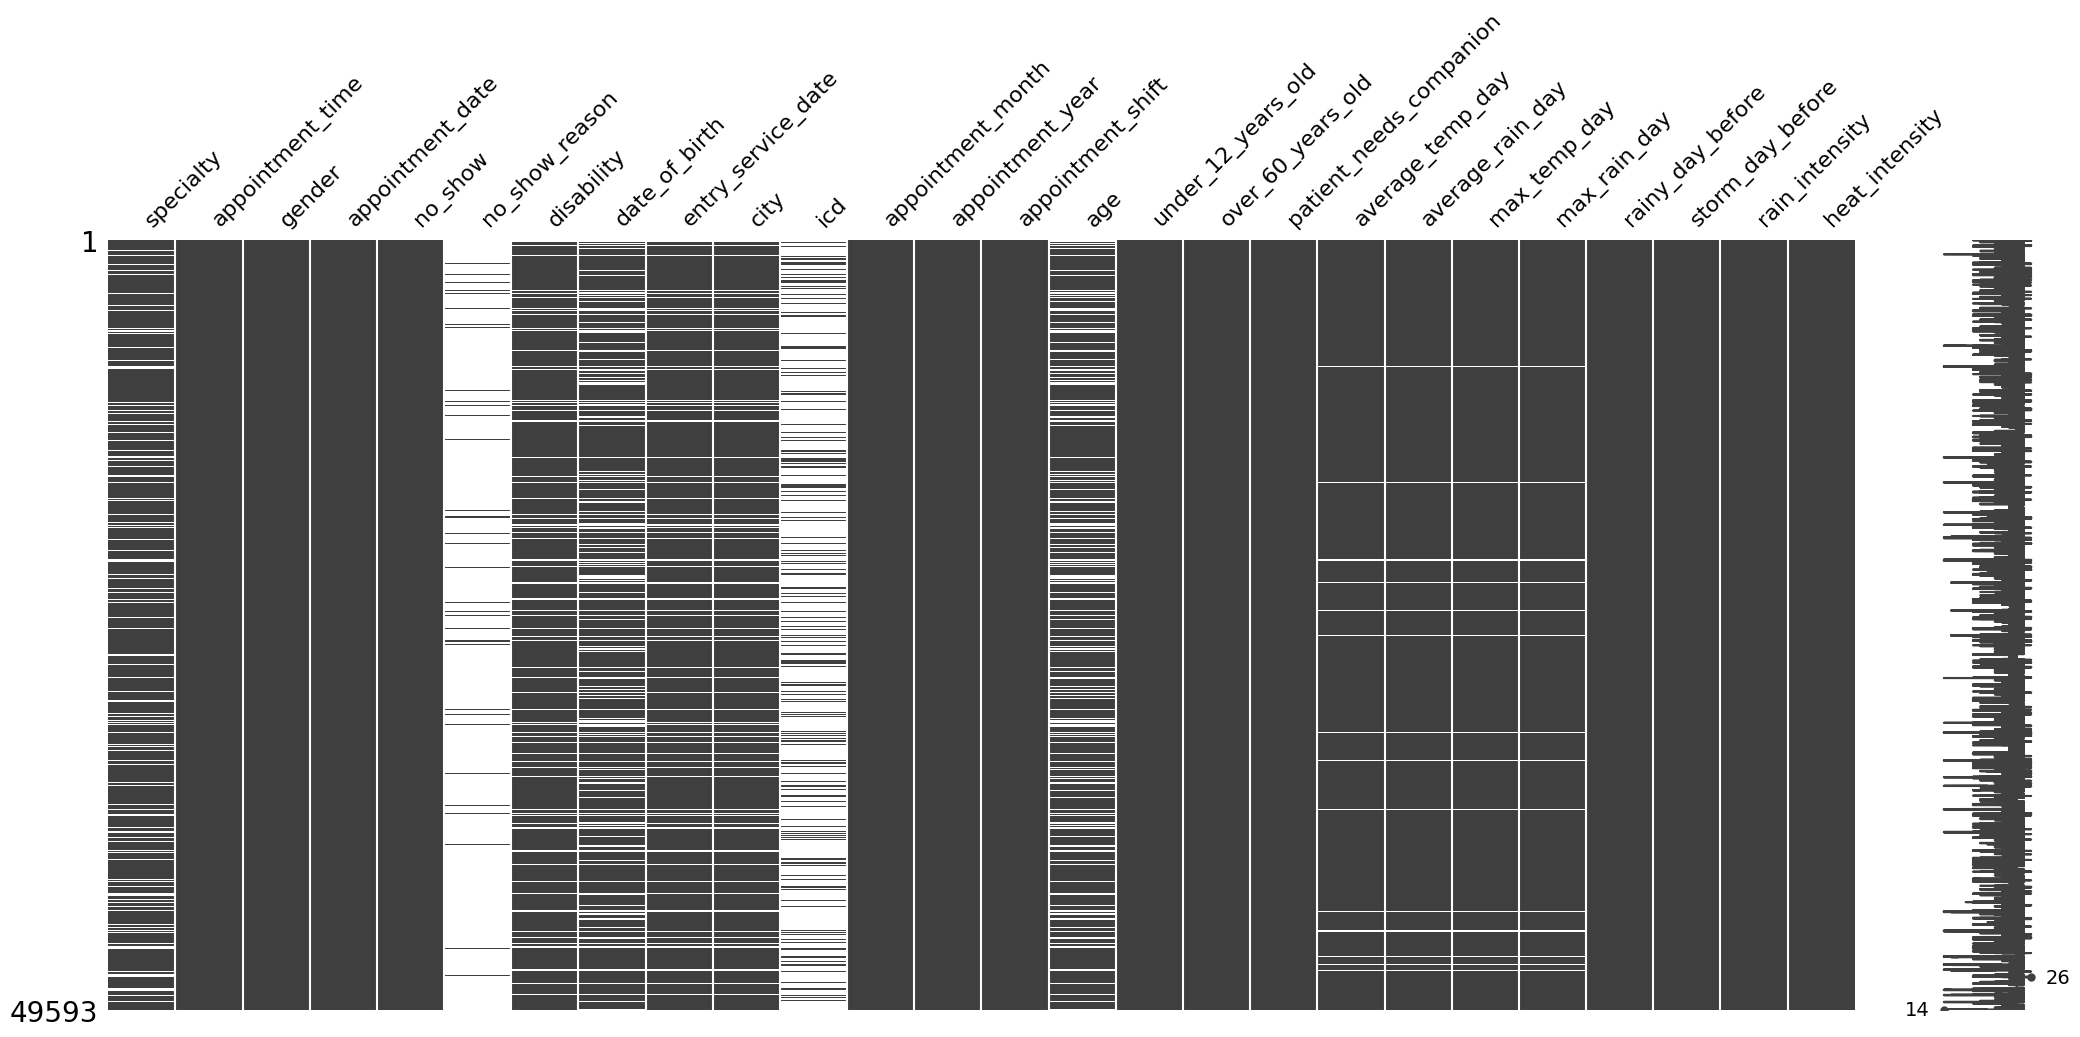

In [206]:
# Visualize missing values
import missingno as msno
msno.matrix(df) 

## Data Cleaning 

In [207]:
df.isnull().sum()

specialty                   7454
appointment_time               0
gender                         0
appointment_date               0
no_show                        0
no_show_reason             47856
disability                  5137
date_of_birth              10321
entry_service_date          5155
city                        5181
icd                        38876
appointment_month              0
appointment_year               0
appointment_shift              0
age                        10350
under_12_years_old             0
over_60_years_old              0
patient_needs_companion        0
average_temp_day            1016
average_rain_day            1016
max_temp_day                1016
max_rain_day                1016
rainy_day_before               0
storm_day_before               0
rain_intensity                 0
heat_intensity                 0
dtype: int64

In [208]:
### Handle Missing Values:
## Specialty: filled with "unknown or mode"
## No-show Reasons: missing most of the values -> drop this column
df = df.drop(columns=['no_show_reason'])
## City: filled with unknown
df.city = df.city.fillna('unknown')
df.city.value_counts()

city
ITAJAÍ            20515
B. CAMBORIU        6018
CAMBORIU           5523
unknown            5181
NAVEGANTES         3901
ITAPEMA            2665
BOMBINHAS          1707
PENHA              1039
PORTO BELO          950
BALN. PIÇARRAS      945
ILHOTA              583
LUIZ ALVES          523
MONTENEGRO           27
BLUMENAU             16
Name: count, dtype: int64

In [209]:
df.disability.fillna("none", inplace=True)

/var/folders/yg/s29l_n4164g5trz13ydf8dzr0000gp/T/ipykernel_61394/3229681348.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.disability.fillna("none", inplace=True)


In [210]:
## ICD: missing most of the values -> drop this column
# df = df.drop(columns=['icd'])

In [211]:
## Specialty: filled with unknown
df.specialty = df.specialty.fillna('unknown')
df.specialty.value_counts()

specialty
speech therapy          11877
psychotherapy           11675
physiotherapy            9074
unknown                  7454
occupational therapy     6486
pedagogo                 2064
enf                       712
assist                    194
sem especialidade          57
Name: count, dtype: int64

In [212]:
# Check duplicates
df[df.duplicated()]

,specialty,appointment_time,gender,appointment_date,no_show,disability,date_of_birth,entry_service_date,city,icd,...,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity
100,psychotherapy,14:00,M,09/08/2021,no,none,NaN,NaN,unknown,NaN,...,0,0,18.25,0.00,21.9,0.0,1,1,no_rain,cold
367,unknown,08:40,M,09/07/2021,yes,intellectual,22/11/2016,9/6/2020,NAVEGANTES,F84,...,0,1,16.63,0.00,21.3,0.0,1,1,no_rain,cold
781,speech therapy,13:00,M,09/04/2018,no,intellectual,13/7/2012,4/7/2016,ITAJAÍ,NaN,...,0,1,23.58,0.01,28.5,0.2,1,1,no_rain,warm
786,speech therapy,17:25,M,09/04/2018,no,intellectual,30/8/2010,9/10/2017,ITAJAÍ,NaN,...,0,1,23.58,0.01,28.5,0.2,1,1,no_rain,warm
903,psychotherapy,17:00,M,09/12/2021,no,none,NaN,NaN,unknown,NaN,...,0,0,20.25,0.00,23.1,0.0,1,1,no_rain,mild
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49579,unknown,08:40,M,01/02/2022,no,none,NaN,NaN,unknown,NaN,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49580,unknown,08:40,M,01/02/2022,no,none,NaN,NaN,unknown,NaN,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49581,unknown,08:40,M,01/02/2022,no,none,NaN,NaN,unknown,NaN,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49582,unknown,08:40,M,01/02/2022,yes,intellectual,18/8/2016,23/10/2019,ITAJAÍ,R68,...,0,1,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold


In [213]:
## Remove the duplicates
df.drop_duplicates(inplace=True)

In [214]:
## Drop the date of birth as we have age
df.drop(columns=['date_of_birth'], inplace=True)

In [215]:
df = df.drop(columns=['entry_service_date'])

In [216]:
# # fill missing average weather data with the mean temperature of that city from other days
# weather_cols = ['average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day']

# for col in weather_cols: 
#     df[col] = df.groupby(['city', 'appointment_month'])[col].transform(lambda x: x.fillna(x.mean()))

In [217]:
df.average_temp_day.value_counts()

average_temp_day
21.13    299
22.83    293
22.77    268
21.88    264
21.26    245
        ... 
14.98      3
25.36      2
21.19      2
18.97      1
22.28      1
Name: count, Length: 677, dtype: int64

In [218]:
df.isnull().sum()

specialty                      0
appointment_time               0
gender                         0
appointment_date               0
no_show                        0
disability                     0
city                           0
icd                        36425
appointment_month              0
appointment_year               0
appointment_shift              0
age                         8691
under_12_years_old             0
over_60_years_old              0
patient_needs_companion        0
average_temp_day             704
average_rain_day             704
max_temp_day                 704
max_rain_day                 704
rainy_day_before               0
storm_day_before               0
rain_intensity                 0
heat_intensity                 0
dtype: int64

In [219]:
df.head(5)

,specialty,appointment_time,gender,appointment_date,no_show,disability,city,icd,appointment_month,appointment_year,...,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity
0,physiotherapy,13:20,M,09/09/2021,yes,none,unknown,NaN,sept,2021,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
1,psychotherapy,13:20,M,09/09/2021,no,none,unknown,NaN,sept,2021,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
2,speech therapy,13:20,F,09/09/2021,no,none,unknown,NaN,sept,2021,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
3,physiotherapy,13:20,F,09/09/2021,no,none,unknown,NaN,sept,2021,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
4,physiotherapy,14:00,M,09/09/2021,no,motor,B. CAMBORIU,I67,sept,2021,...,1,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild


###  Feature Engineering

In [220]:

# Save the cleaned dataset
df.to_csv('../data/cleaned_data.csv', index=False)


In [221]:
df = pd.read_csv('../data/cleaned_data.csv')
df.head(5)


,specialty,appointment_time,gender,appointment_date,no_show,disability,city,icd,appointment_month,appointment_year,...,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity
0,physiotherapy,13:20,M,09/09/2021,yes,none,unknown,NaN,sept,2021,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
1,psychotherapy,13:20,M,09/09/2021,no,none,unknown,NaN,sept,2021,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
2,speech therapy,13:20,F,09/09/2021,no,none,unknown,NaN,sept,2021,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
3,physiotherapy,13:20,F,09/09/2021,no,none,unknown,NaN,sept,2021,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
4,physiotherapy,14:00,M,09/09/2021,no,motor,B. CAMBORIU,I67,sept,2021,...,1,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild


In [222]:
df.nunique()
# Save the cleaned dataset


specialty                     9
appointment_time             74
gender                        3
appointment_date           1001
no_show                       2
disability                    4
city                         14
icd                          63
appointment_month            12
appointment_year              7
appointment_shift             2
age                          87
under_12_years_old            2
over_60_years_old             2
patient_needs_companion       2
average_temp_day            677
average_rain_day            130
max_temp_day                185
max_rain_day                 84
rainy_day_before              2
storm_day_before              2
rain_intensity                4
heat_intensity                5
dtype: int64

In [223]:
df.rain_intensity.value_counts()

rain_intensity
no_rain     33264
moderate     6621
weak         4483
heavy        2273
Name: count, dtype: int64

In [224]:

df.gender = df.gender.map({'M': 1, 'F': 0})
df.no_show = df.no_show.map({'yes': 1, 'no': 0})

In [225]:
df['has_icd'] = df['icd'].notna().astype(int)

In [226]:
# 基於no-show率的pattern，建議這樣分組
bins = [0, 18, 30, 45, 60, 75, 115]
labels = ['Under 18', '18-30', '31-45', '46-60', '61-75', '75+']

df['age_group'] = pd.cut(df['age'], 
                        bins=bins, 
                        labels=labels, 
                        right=False)

In [227]:
df.age_group.value_counts()
# 檢查原始age列的缺失值
print("Missing values in age column:", df['age'].isna().sum())

# 檢查age的範圍
print("\nAge range:")
print("Min age:", df['age'].min())
print("Max age:", df['age'].max())

# 檢查異常值
print("\nUnique age values:", sorted(df['age'].unique()))

# 比較前後數量
print("\nOriginal age count:", len(df['age']))
print("Age group count:", len(df['age_group'].dropna()))

# 檢查哪些age值沒有被分組
mask = df['age_group'].isna()
print("\nAge values not grouped:", df[mask]['age'].unique())

Missing values in age column: 8691

Age range:
Min age: 2.0
Max age: 110.0

Unique age values: [np.float64(nan), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(52

In [228]:
df = pd.get_dummies(df, columns=['age_group'], prefix=['age'])

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46641 entries, 0 to 46640
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   specialty                46641 non-null  object 
 1   appointment_time         46641 non-null  object 
 2   gender                   46634 non-null  float64
 3   appointment_date         46641 non-null  object 
 4   no_show                  46641 non-null  int64  
 5   disability               46641 non-null  object 
 6   city                     46641 non-null  object 
 7   icd                      10216 non-null  object 
 8   appointment_month        46641 non-null  object 
 9   appointment_year         46641 non-null  int64  
 10  appointment_shift        46641 non-null  object 
 11  age                      37950 non-null  float64
 12  under_12_years_old       46641 non-null  int64  
 13  over_60_years_old        46641 non-null  int64  
 14  patient_needs_companio

In [230]:
df.rain_intensity.unique()

array(['no_rain', 'moderate', 'weak', 'heavy'], dtype=object)

In [231]:
# 'no_rain', 'weak', 'moderate', 'heavy'
rain_intensity = {'no_rain': 0, 'weak':1, 'moderate': 2, 'heavy': 3}
df.rain_intensity = df.rain_intensity.map(rain_intensity)

# 'mild', 'cold', 'warm', 'heavy_cold', 'heavy_warm'
heat_intensity = {'heavy_cold': 0, 'cold': 1, 'mild': 2, 'warm': 3, 'heavy_warm': 4}
df.heat_intensity = df.heat_intensity.map(heat_intensity)

In [232]:
print(df.heat_intensity.unique())
print(df.rain_intensity.unique())

[2 1 3 0 4]
[0 2 1 3]


In [233]:
df.appointment_shift.unique()
# 'morning', 'afternoon'
df.appointment_shift = df.appointment_shift.map({'morning': 1, 'afternoon': 0})

In [234]:
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%d/%m/%Y')
df['appointment_time'] = pd.to_datetime(df['appointment_time'], format='%H:%M').dt.time
df

,specialty,appointment_time,gender,appointment_date,no_show,disability,city,icd,appointment_month,appointment_year,...,storm_day_before,rain_intensity,heat_intensity,has_icd,age_Under 18,age_18-30,age_31-45,age_46-60,age_61-75,age_75+
0,physiotherapy,13:20:00,1.0,2021-09-09,1,none,unknown,NaN,sept,2021,...,1,0,2,0,False,False,False,False,False,False
1,psychotherapy,13:20:00,1.0,2021-09-09,0,none,unknown,NaN,sept,2021,...,1,0,2,0,False,False,False,False,False,False
2,speech therapy,13:20:00,0.0,2021-09-09,0,none,unknown,NaN,sept,2021,...,1,0,2,0,False,False,False,False,False,False
3,physiotherapy,13:20:00,0.0,2021-09-09,0,none,unknown,NaN,sept,2021,...,1,0,2,0,False,False,False,False,False,False
4,physiotherapy,14:00:00,1.0,2021-09-09,0,motor,B. CAMBORIU,I67,sept,2021,...,1,0,2,1,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46636,psychotherapy,10:20:00,1.0,2022-02-01,0,intellectual,BOMBINHAS,F84,feb,2022,...,0,0,0,1,True,False,False,False,False,False
46637,unknown,10:20:00,1.0,2022-02-01,1,none,unknown,NaN,feb,2022,...,0,0,0,0,False,False,False,False,False,False
46638,unknown,11:00:00,1.0,2022-02-01,0,intellectual,BOMBINHAS,F84,feb,2022,...,0,0,0,1,True,False,False,False,False,False
46639,psychotherapy,11:00:00,1.0,2022-02-01,1,none,unknown,NaN,feb,2022,...,0,0,0,0,False,False,False,False,False,False


In [235]:
# Extract Month and Day from the appointment date and add weekday and weekend indicator
df['day_of_week'] = df['appointment_date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['appointment_month'] = df['appointment_date'].dt.month
df['appointment_year'] = df['appointment_date'].dt.year
df['appointment_day'] = df['appointment_date'].dt.day

In [236]:
df['appointment_hour'] = pd.to_datetime(df['appointment_time'], format='%H:%M:%S').dt.hour


In [237]:
# One-hot encode the categorical features
df = pd.get_dummies(df, columns=['city', 'specialty', 'disability', 'day_of_week', 'appointment_hour', 'appointment_month', 'appointment_year'], drop_first=True)

In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46641 entries, 0 to 46640
Data columns (total 85 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   appointment_time                46641 non-null  object        
 1   gender                          46634 non-null  float64       
 2   appointment_date                46641 non-null  datetime64[ns]
 3   no_show                         46641 non-null  int64         
 4   icd                             10216 non-null  object        
 5   appointment_shift               46641 non-null  int64         
 6   age                             37950 non-null  float64       
 7   under_12_years_old              46641 non-null  int64         
 8   over_60_years_old               46641 non-null  int64         
 9   patient_needs_companion         46641 non-null  int64         
 10  average_temp_day                45937 non-null  float64       
 11  av

In [239]:
df = df.drop(columns=['appointment_day'])

In [240]:
df.drop(columns=['appointment_date', 'appointment_time'], inplace=True)


In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46641 entries, 0 to 46640
Data columns (total 82 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          46634 non-null  float64
 1   no_show                         46641 non-null  int64  
 2   icd                             10216 non-null  object 
 3   appointment_shift               46641 non-null  int64  
 4   age                             37950 non-null  float64
 5   under_12_years_old              46641 non-null  int64  
 6   over_60_years_old               46641 non-null  int64  
 7   patient_needs_companion         46641 non-null  int64  
 8   average_temp_day                45937 non-null  float64
 9   average_rain_day                45937 non-null  float64
 10  max_temp_day                    45937 non-null  float64
 11  max_rain_day                    45937 non-null  float64
 12  rainy_day_before                

In [242]:
df.nunique()
df.gender.unique()
# Drop the rows with unknown gender
df = df.dropna(subset=['gender'])

In [243]:
# Save the cleaned and Encoded dataset
df.to_csv('../data/cleaned_encoded_data.csv', index=False)

In [244]:
df.under_12_years_old.value_counts()

under_12_years_old
0    24117
1    22517
Name: count, dtype: int64

In [245]:
df.over_60_years_old.value_counts()

over_60_years_old
0    43106
1     3528
Name: count, dtype: int64

In [246]:
df.storm_day_before.value_counts()

storm_day_before
1    45967
0      667
Name: count, dtype: int64

In [247]:
df.is_weekend.value_counts()

is_weekend
0    45653
1      981
Name: count, dtype: int64

In [248]:
df.nunique()

gender                    2
no_show                   2
icd                      63
appointment_shift         2
age                      87
                         ..
appointment_year_2018     2
appointment_year_2019     2
appointment_year_2020     2
appointment_year_2021     2
appointment_year_2022     2
Length: 82, dtype: int64

In [249]:
df.isnull().sum()

gender                       0
no_show                      0
icd                      36418
appointment_shift            0
age                       8691
                         ...  
appointment_year_2018        0
appointment_year_2019        0
appointment_year_2020        0
appointment_year_2021        0
appointment_year_2022        0
Length: 82, dtype: int64

In [250]:
df.isnull().sum()

gender                       0
no_show                      0
icd                      36418
appointment_shift            0
age                       8691
                         ...  
appointment_year_2018        0
appointment_year_2019        0
appointment_year_2020        0
appointment_year_2021        0
appointment_year_2022        0
Length: 82, dtype: int64